# Lab 2 - Comitês (Ensembles)

Classificadores: **Random Forest**, **AdaBoost** e **XGBoost**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lab2_utils import (
    carregar_dados, avaliar_modelo, logar_mlflow, iniciar_run,
    calibrar_threshold, predizer_com_threshold,
)

X_train, y_train, X_test, y_test = carregar_dados()

# Split de validação dentro do treino — usado para calibrar threshold
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

Iniciando servidor MLflow em background...


Servidor MLflow pronto em http://127.0.0.1:5000
Dados carregados (gerados em 2026-06-25 21:29)
  X_train: (440832, 10)  |  X_test: (64374, 10)
  Features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']
  Churn rate treino: 0.567  |  teste: 0.474


## Random Forest

Threshold calibrado: 0.3382

=== RandomForest ===
              precision    recall  f1-score   support

Não cancelou       0.98      0.09      0.16     33881
    Cancelou       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.54      0.41     64374
weighted avg       0.75      0.52      0.40     64374

Balanced Accuracy: 0.5431  |  Kappa: 0.0820


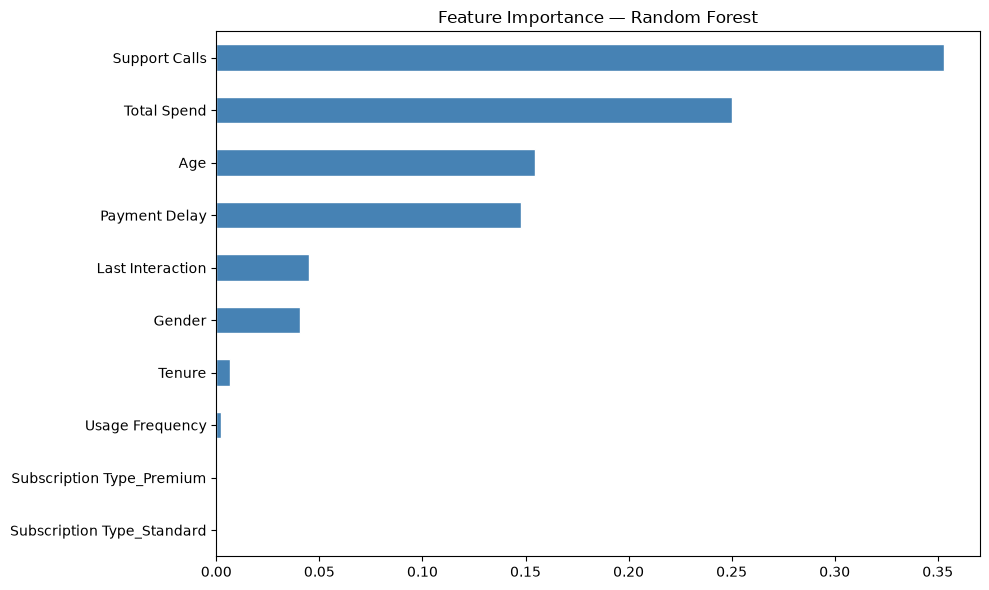

🏃 View run RandomForest at: http://127.0.0.1:5000/#/experiments/1/runs/4371e62df24e4f56b6d2ac3ebbc35dfc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [2]:
# ─── Random Forest ──────────────────────────────────────────────
# Threshold calibrado via predict_proba substitui class_weight='balanced'.
from sklearn.ensemble import RandomForestClassifier

params = {
    'modelo': 'RandomForest',
    'n_estimators': 200,
    'max_depth': 10,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'scaler': 'nenhum (dados já escalados)',
}

with iniciar_run("RandomForest", notebook="2C", params=params):
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)

    threshold = calibrar_threshold(model, X_val, y_val)
    y_pred = predizer_com_threshold(model, X_test, threshold)
    params['threshold'] = round(threshold, 4)
    print(f'Threshold calibrado: {threshold:.4f}')

    metricas = avaliar_modelo('RandomForest', y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 6))
    importances = pd.Series(model.feature_importances_, index=X_tr.columns).sort_values()
    importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Feature Importance — Random Forest')
    plt.tight_layout()
    fi_path = '../relatorio/imagens/2c_com_feature_importance_rf.png'
    plt.savefig(fi_path, dpi=150, bbox_inches='tight')
    plt.show()

    logar_mlflow(metricas, params, artefatos=[fi_path])

## AdaBoost

In [3]:
# ─── AdaBoost ───────────────────────────────────────────────────
# Threshold calibrado via predict_proba no split de validação.
from sklearn.ensemble import AdaBoostClassifier

params = {
    'modelo': 'AdaBoost',
    'n_estimators': 200,
    'learning_rate': 0.05,
    'scaler': 'nenhum (dados já escalados)',
}

with iniciar_run("AdaBoost", notebook="2C", params=params):
    model = AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
    )
    model.fit(X_tr, y_tr)

    threshold = calibrar_threshold(model, X_val, y_val)
    y_pred = predizer_com_threshold(model, X_test, threshold)
    params['threshold'] = round(threshold, 4)
    print(f'Threshold calibrado: {threshold:.4f}')

    metricas = avaliar_modelo('AdaBoost', y_test, y_pred)
    logar_mlflow(metricas, params)

Threshold calibrado: 0.4550

=== AdaBoost ===
              precision    recall  f1-score   support

Não cancelou       0.98      0.16      0.27     33881
    Cancelou       0.52      1.00      0.68     30493

    accuracy                           0.55     64374
   macro avg       0.75      0.58      0.47     64374
weighted avg       0.76      0.55      0.46     64374

Balanced Accuracy: 0.5764  |  Kappa: 0.1459


🏃 View run AdaBoost at: http://127.0.0.1:5000/#/experiments/1/runs/9eefa55b727f471e9a69092cf1d5014d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## XGBoost

In [4]:
# ─── XGBoost ────────────────────────────────────────────────────
# Threshold calibrado via predict_proba substitui scale_pos_weight.
from xgboost import XGBClassifier

params = {
    'modelo': 'XGBoost',
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.05,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scaler': 'nenhum (dados já escalados)',
}

with iniciar_run("XGBoost", notebook="2C", params=params):
    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
    )
    model.fit(X_tr, y_tr)

    threshold = calibrar_threshold(model, X_val, y_val)
    y_pred = predizer_com_threshold(model, X_test, threshold)
    params['threshold'] = round(threshold, 4)
    print(f'Threshold calibrado: {threshold:.4f}')

    metricas = avaliar_modelo('XGBoost', y_test, y_pred)
    logar_mlflow(metricas, params)

Threshold calibrado: 0.3962

=== XGBoost ===
              precision    recall  f1-score   support

Não cancelou       0.98      0.09      0.16     33881
    Cancelou       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.54      0.41     64374
weighted avg       0.75      0.52      0.40     64374

Balanced Accuracy: 0.5426  |  Kappa: 0.0811


🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/e82a354a65ae4dd38804afe4a30c031d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
